# Introduction

This notebook was created for other students, in the hope of helping them better and more practically understand the concepts behind neuromorphic computing.
Although it is simple and mostly straightforward from a coding point of view, I think the ideas behind these graphs are easier to understand when they are visualized in an interactive way.

Since I am not an expert in the field, any help in improving this project is very welcome!

The project is structured as follows: each theoretical concept is presented with a brief description, followed by a graphical representation.

This work is based on the *Neuromorphic Engineering* course offered by the University of Genoa.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, widgets
import math 
from scipy.fft import fft, fft2, fftshift, ifft2, ifftshift, fftfreq

%matplotlib inline

# Difference of gaussians (DoG)

## 1D DoG

The Difference of Gaussians (DoG) is a model commonly used to approximate receptive fields in early visual processing. It is obtained by subtracting a broader Gaussian (the surround) from a narrower one (the center). This structure closely resembles the center-surround organization observed in retinal ganglion cells, such as On-Off cells.

In the frequency domain, the DoG behaves as a band-pass filter: it attenuates both very low and very high spatial frequencies while responding maximally to intermediate ones. As a consequence, uniform (constant) inputs do not elicit a response, since they correspond to zero spatial frequency, which is suppressed by the filter.

The equation for the DoG is defined in the following way: $$ h_{rgc}(x,\sigma_{rgc}) = G_c(x, \sigma_c)-G_s(x, \sigma_s) $$  
Where $h_{rgc}$ is the receptive field for a retinal ganglion cell, and $G_c$ and $G_s$ are respectively the center and the surround gaussians

The left plot shows the DoG in the spatial domain, highlighting the central excitatory region and the inhibitory surround. The right plot displays the corresponding frequency representation, where the band-pass characteristic is evident from the peak at intermediate frequencies and attenuation at low frequencies.

**Parameters:**  
Sigma center ($\sigma_c$): controls the width of the central Gaussian.  
Sigma surround ($\sigma_s$): controls the width of the surrounding Gaussian.


In [ ]:
def plot_dog(sigma_c, sigma_s):

    if sigma_c >= sigma_s:
        print("NOTE: sigma_c should be smaller than sigma_s for a standard positive DoG profile.") 

    # Setup Space and number of points
    n_points = 1000
    x_min, x_max = -50, 50
    space = np.linspace(x_min, x_max, n_points)
    
    # Calculate Sampling Interval (dx) 
    dx = space[1] - space[0]
    
    # Calculate Gaussians
    gc = (1 / (sigma_c * np.sqrt(2 * np.pi))) * np.exp(-(space**2) / (2 * sigma_c**2))
    gs = (1 / (sigma_s * np.sqrt(2 * np.pi))) * np.exp(-(space**2) / (2 * sigma_s**2))
    
    # Normalize by sum to ensure DoG response is controlled
    gc /= np.sum(gc)
    gs /= np.sum(gs)
    dog = gc - gs

    # Frequency Domain Calculation
    # fftfreq creates the correct frequency bins based on number of points and spacing
    freqs = fftshift(fftfreq(n_points, d=dx))
    
    gc_fft = np.abs(fftshift(fft(gc)))
    gs_fft = np.abs(fftshift(fft(gs)))
    dog_fft = np.abs(fftshift(fft(dog)))

    # Plotting
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    
    # Spatial Domain Plot
    ax[0].axhline(0, c="black", linestyle="--", alpha=0.3)
    ax[0].axvline(0, c="black", linestyle="--", alpha=0.1)
    ax[0].plot(space, gc, label="Center ($G_c$)", c="green", alpha=0.7)
    ax[0].plot(space, -gs, label="Surround ($-G_s$)",c="red", alpha=0.7)
    ax[0].plot(space, dog, label="DoG", lw=2, color='blue', alpha=0.4)

    # graphical settings for spatial domain
    ax[0].set_title("Spatial Domain (Image Space)")
    ax[0].set_xlabel("space")
    ax[0].set_xlim(-15, 15)
    ax[0].set_ylim(np.min(-gs)*1.25, np.max(gc)*1.25) 
    ax[0].legend()

    # Frequency Domain Plot
    ax[1].axhline(0, c="black", linestyle="--", alpha=0.3)
    ax[1].axvline(0, c="black", linestyle="--", alpha=0.1)
    ax[1].plot(freqs, gc_fft, label="$|FFT(G_c)|$",c="green", alpha=0.7)
    ax[1].plot(freqs, -gs_fft, label="$-|FFT(G_s)|$",c="red", alpha=0.7)
    ax[1].plot(freqs, dog_fft, label="DoG Frequency Response", lw=2, color='blue', alpha=0.4)
    
    
    # graphical settings for frequency domain
    ax[1].set_title("DoG in frequency Domain")
    ax[1].set_xlabel("Frequency")
    ax[1].set_ylabel("Magnitude")
    ax[1].set_xlim(-1, 1)
    ax[1].legend()
     
    
    plt.tight_layout()
    plt.show()

# Interactive plot
interact(plot_dog, 
         sigma_c=widgets.FloatSlider(value=0.5, min=0.1, max=2.0, step=0.01, description='sigma Center'),
         sigma_s=widgets.FloatSlider(value=1.5, min=0.1, max=5.0, step=0.01, description='sigma Surround'))

interactive(children=(FloatSlider(value=0.5, description='sigma Center', max=2.0, min=0.1, step=0.01), FloatSl…

<function __main__.plot_dog(sigma_c, sigma_s)>

## 2D DoG (colormap)

As in the previous example, the Difference of Gaussians (DoG) is used to model center-surround receptive fields. In this case, the DoG is constructed from two two-dimensional Gaussian functions: a narrower Gaussian representing the excitatory center and a broader one representing the inhibitory surround.

This 2D formulation provides a more realistic representation of spatial receptive fields, as it captures how neurons respond to stimuli distributed across both spatial dimensions. The resulting structure emphasizes local contrast, responding strongly to intensity variations while suppressing uniform regions.

The figure shows the spatial representation of a 2D DoG. The central bright region corresponds to the excitatory Gaussian, while the surrounding darker area represents the inhibitory component. The red circle highlights the approximate extent of the center region, helping to visualize the relative size of the two components.

**Parameters:**  
Sigma center ($\sigma_c$): controls the width of the central Gaussian.  
Sigma surround ($\sigma_s$): controls the width of the surrounding Gaussian.

In [ ]:
# Setup the grid
x = np.linspace(-20, 20, 200)
y = np.linspace(-20, 20, 200)
X, Y = np.meshgrid(x, y)

def plot_dog(sigmac, sigmas):

    # warning when sigmas is smaller than sigmac
    if sigmac >= sigmas:
        print("NOTE: sigmac should be smaller than sigmas for a standard positive DoG profile.")
    
    # Calculate Gaussians
    Gc = (1 / (2 * np.pi * sigmac**2)) * np.exp(-(X**2 + Y**2) / (2 * sigmac**2))
    Gc = Gc / np.sum(Gc)
    
    Gs = (1 / (2 * np.pi * sigmas**2)) * np.exp(-(X**2 + Y**2) / (2 * sigmas**2))
    Gs = Gs / np.sum(Gs)
    
    Z = Gc - Gs

    # Plotting
    plt.figure(figsize=(10, 8))
    im = plt.pcolormesh(X, Y, Z, cmap='viridis', shading='auto')
    plt.colorbar(im)
    
    # Zero crossing contour
    plt.contour(X, Y, Z, levels=[0], colors='red', linewidths=2)
    
    plt.title(f'Difference of Gaussians colormap')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.show()

# Interactive plot
interact(plot_dog, 
         sigmac=FloatSlider(value=1, min=0, max=10.0, step=0.1, description='Sigma Center:'),
         sigmas=FloatSlider(value=2, min=0., max=15.0, step=0.1, description='Sigma Surround:'))

interactive(children=(FloatSlider(value=1.0, description='Sigma Center:', max=10.0), FloatSlider(value=2.0, de…

<function __main__.plot_dog(sigmac, sigmas)>

## 3D DoG

**Parameters:**  
Sigma center ($\sigma_c$): controls the width of the central Gaussian.  
Sigma surround ($\sigma_s$): controls the width of the surrounding Gaussian.  
Elevation, Azimuth: angle of graph visualization

In [ ]:
from ipywidgets import interact, FloatSlider
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-20, 20, 100)
y = np.linspace(-20, 20, 100)
X, Y = np.meshgrid(x, y)

def update_plots(sigmac, sigmas, elev, azim):
    if sigmac == 0 or sigmas == 0:
        print("Sigma must be > 0")
        return

    Gc = (1 / (2 * np.pi * sigmac**2)) * np.exp(-(X**2 + Y**2) / (2 * sigmac**2))
    Gc /= np.sum(Gc)

    Gs = (1 / (2 * np.pi * sigmas**2)) * np.exp(-(X**2 + Y**2) / (2 * sigmas**2))
    Gs /= np.sum(Gs)

    Z = Gc - Gs

    fig = plt.figure(figsize=(20, 8))
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')

    ax1.plot_surface(X, Y, Z, cmap='viridis')
    ax1.set_title('Interactive DoG Surface')

    ax2.plot_surface(X, Y, Gc, cmap='viridis', alpha=0.7)
    ax2.plot_surface(X, Y, -Gs, cmap='viridis', alpha=0.7)
    ax2.set_title('Center and Surround')
    
    # turn off axes grid for better visualization
    ax1.grid(False)
    ax2.grid(False)

    # Match colorbars for both plots
    mappable1 = plt.cm.ScalarMappable(cmap='viridis')
    mappable1.set_array(Z)
    plt.colorbar(mappable1, ax=ax1, shrink=0.5, aspect=10)
    plt.colorbar(mappable1, ax=ax2, shrink=0.5, aspect=10)

    # plot rotation angles
    ax1.view_init(elev=elev, azim=azim)
    ax2.view_init(elev=elev, azim=azim)

    plt.show()

interact(update_plots,
         sigmac=FloatSlider(value=1, min=0.1, max=10.0, step=0.1, description='Sigma Center:'),
         sigmas=FloatSlider(value=2, min=0.1, max=15.0, step=0.1, description='Sigma Surround:'),
         elev=FloatSlider(value=0, min=-90, max=90, step=1, description='Elevation:'),
         azim=FloatSlider(value=0, min=0, max=360, step=1, description='Azimuth:'))

interactive(children=(FloatSlider(value=1.0, description='Sigma Center:', max=10.0, min=0.1), FloatSlider(valu…

<function __main__.update_plots(sigmac, sigmas, elev, azim)>

# Gabor functions

## 1D gabor functions

Gabor functions are a particular class of function used for the modelling of receptive fields. These functions are obtained by multiplying a complex exponential with a gaussian envelope:

$$ h(x) = G(x, \sigma) e^{-jk_0x} $$

where j is the imaginary unit, $k_0$ is the peak frequency, and $\sigma$ is the standard deviation of the gaussian envelope.

**Parameters**:  
$k_0$: peak frequency  
sigma ($\sigma$): width of the gaussian envelope  
gauss shift: shift of the gaussian curve  
sin shift: shift of the sinusoid curve

In [ ]:
# Parameters (adjust as needed)
k0 = 2 * np.pi * 1.0    # angular frequency
sigma = 0.6           # Gaussian standard deviation
x0 = 0.0                # Gaussian center
xs0 = 0.0               # Sinusoid center
x_min, x_max = -4.0, 4.0
n_points = 1200

def plot_gabor_functions(k0, sigma, x0, xs0):

    # Domain and functions
    x = np.linspace(x_min, x_max, n_points)
    gauss = np.exp(-((x - x0) ** 2) / (2 * sigma ** 2))
    complex_sinusoid = np.exp(-1j * k0 * (x-xs0))
    gabor = gauss * complex_sinusoid

    fig, ax = plt.subplots(1,2, figsize=(14, 5))

    # Real part
    ax[0].plot(x, gabor.real)
    ax[0].plot(x, complex_sinusoid.real, label='Real part of complex sinusoid', c='green', alpha=0.2)
    ax[0].set_title("Gabor (real part): $g(x)\\,\\mathrm{Re}\\{e^{-j k_0 x}\\}$")
    ax[0].set_ylabel("Real(gabor)")
    ax[0].grid(True)

    # plot the gaussian envelope 
    ax[0].plot(x, gauss, label='Gaussian Envelope', c='gray', alpha=0.5)
    ax[0].plot(x, -gauss, label='Gaussian Envelope', c='gray', alpha=0.5)

    # Imaginary part
    ax[1].plot(x, gabor.imag)
    ax[1].plot(x, complex_sinusoid.imag, label='Imaginary part of complex sinusoid', c='green', alpha=0.2)
    ax[1].set_title("Gabor (imag part): $g(x)\\,\\mathrm{Im}\\{e^{-j k_0 x}\\}$")
    ax[1].set_ylabel("Imag(gabor)")
    ax[1].grid(True)

    # plot the gaussian envelope
    ax[1].plot(x, gauss, label='Gaussian Envelope', c='gray', alpha=0.5)
    ax[1].plot(x, -gauss, label='Gaussian Envelope', c='gray', alpha=0.5)

    plt.show()
interact(plot_gabor_functions,
         k0=FloatSlider(value=2*np.pi, min=0.1, max=20*np.pi, step=0.1, description='k0:'),
         sigma=FloatSlider(value=0.6, min=0.1, max=5.0, step=0.1, description='Sigma:'),
         x0=FloatSlider(value=0.0, min=-2.0, max=2.5, step=0.1, description='Gauss shift:'),
         xs0=FloatSlider(value=0.0, min=-2.0, max=2.5, step=0.1, description='Sin shift:'))

interactive(children=(FloatSlider(value=6.283185307179586, description='k0:', max=62.83185307179586, min=0.1),…

<function __main__.plot_gabor_functions(k0, sigma, x0, xs0)>

## 2D gabor functions

Gabor functions are a particular class of function used for the modelling of receptive fields. These functions are obtained by multiplying a complex exponential with a gaussian envelope:

$$ h(\underline{x}) = G(\underline{x}, \sigma) e^{-jk_0x} $$

where j is the imaginary unit, $k_0$ is the peak frequency, $\sigma$ is the standard deviation of the gaussian envelope, and x (the one without the underbar) indicates only the horizontal spatial component.

**Parameters**:  
$k_0$: Peak frequency  
Sigma ($\sigma$): Width of the gaussian envelope  
theta ($\theta$): Angle on which the Gabor function is oriented


In [50]:
# generate a 2d gaussian function
def gaussian_2d(x, y, sigma):
    return (1/(2*np.pi*sigma**2)) * np.exp(-((x**2 + y**2)/(2*sigma**2)))

# generate a 1d complex exponential
def complex_exponential_1d(x, y, k0, theta, offset):
    x_theta = x*np.cos(theta) + y*np.sin(theta)  
    return np.exp(-1j * (k0 * x_theta + offset))

# generate a 2d gabor function
def gabor_2d(x, y, sigma , k0, theta, offset):
    gauss = gaussian_2d(x, y, sigma)
    complex_exp = complex_exponential_1d(x, y, k0, theta, offset)
    return gauss * complex_exp


x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)


sigma = 1


k0 = 2 * np.pi * 0.5 # peak frequency

theta = np.pi * 0  # orientation angle 

offset = np.pi * 0  # phase offset

def update_gabor_2d_plots(sigma, k0, theta, offset):
    gabor = gabor_2d(X, Y, sigma, k0, -theta, offset)

    fig, ax = plt.subplots(1,2, figsize=(12,5))
    ax[0].imshow(np.real(gabor), extent=(-5, 5, -5, 5), cmap='gray_r')
    ax[1].imshow(np.imag(gabor), extent=(-5, 5, -5, 5), cmap='gray_r')

    # plot a red arrow indicating the sensitivity direction
    arrow_length = 2.0
    arrow_x = arrow_length * np.cos(theta)
    arrow_y = arrow_length * np.sin(theta)
    ax[0].arrow(0, 0, arrow_x, arrow_y, head_width=0.3, head_length=0.5, fc='red', ec='red', alpha=0.5)
    ax[1].arrow(0, 0, arrow_x, arrow_y, head_width=0.3, head_length=0.5, fc='red', ec='red', alpha=0.5)

    ax[0].set_title('Real Part (odd)')
    ax[1].set_title('Imaginary Part (even)')
    ax[0].axhline(0, color='black', linestyle='--', alpha=0.2)
    ax[0].axvline(0, color='black', linestyle='--', alpha=0.2)
    ax[1].axhline(0, color='black', linestyle='--', alpha=0.2)
    ax[1].axvline(0, color='black', linestyle='--', alpha=0.2)
    ax[0].set_xticks([])
    ax[0].set_yticks([])
    ax[1].set_xticks([])
    ax[1].set_yticks([])
    fig.suptitle('2D Gabor Function', fontsize=14)
    

    plt.show()

interact(update_gabor_2d_plots,
         sigma=FloatSlider(value=1, min=0.1, max=5.0, step=0.1, description='Sigma:'),
         k0=FloatSlider(value=2*np.pi*0.5, min=0.1, max=20*np.pi, step=0.1, description='k0:'),
         theta=FloatSlider(value=0, min=0, max=np.pi, step=0.01, description='theta:'),
         offset=FloatSlider(value=0, min=0, max=2*np.pi, step=0.01, description='Offset:'))

interactive(children=(FloatSlider(value=1.0, description='Sigma:', max=5.0, min=0.1), FloatSlider(value=3.1415…

<function __main__.update_gabor_2d_plots(sigma, k0, theta, offset)>

# Noise model
The poisson distribution is useful for describing noise in neural networks. The underlying gaussian represent a possible tuning curve of a neuron, which is influenced by a random poissonian process.  
The probability mass function for a poisson distribution is defined as : $$P(X=x)=\frac{\lambda^x e^{-\lambda}}{x!}$$  
Where $x$ is the number of occurences and $\lambda$ is equal to the expected value of $X$ and also to its variance.

**Parameters:**  
Mean ($\mu$): Mean of the gaussian  
Sigma: standard deviation

In [ ]:
# Parameters for the Gaussian
mu = 0.0      # mean
sigma = 1.0   # standard deviation
x = np.linspace(-5, 5, 500)


# Plot
def plot_gaussian_with_poisson_noise(mu, sigma ):

    gaussian = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    gaussian /= gaussian.sum()  # normalize
    N_samples = 50000
    noisy_counts = np.random.poisson(lam=gaussian * N_samples)

    noisy_curve = noisy_counts / noisy_counts.sum()


    fig, ax = plt.subplots(1,2, figsize = (18, 5))
    ax[0].plot(x, gaussian, 'k-', label="Gaussian (ideal)")
    

    # Shaded area showing deviation from Gaussian
    ax[0].fill_between(x, gaussian, noisy_curve, color='red', alpha=0.5)
    
    ax[0].axvline(0, color='black', linestyle='--', alpha=0.2)

    ax[0].set_title("Gaussian with random Poisson Noise")
    ax[0].set_xlabel("x")
    ax[0].set_xlim(-5, 5)
    ax[0].set_ylim(0,0.0075)
    ax[0].legend()

    
    lambda_vals = gaussian * N_samples  
    uncertainty = np.sqrt(lambda_vals) / N_samples  

    ax[1].plot(x, gaussian, 'k-', label="Gaussian (ideal)")
    ax[1].fill_between(x, gaussian - uncertainty, gaussian + uncertainty,
                    color='red', alpha=0.3, label="Poisson uncertainty band")
    
    ax[1].axvline(0, color='black', linestyle='--', alpha=0.2)
    


    ax[1].set_title("Gaussian with poisson PMF")
    ax[1].set_xlabel("x")
    ax[1].set_xlim(-5, 5)
    ax[1].set_ylim(0,0.0075)
    ax[1].legend()
    plt.show()

interact(
    plot_gaussian_with_poisson_noise,
    mu=FloatSlider(value=0.0, min=-2.0, max=2.0, step=0.1, description='Mean (μ):'),
    sigma=FloatSlider(value=1.3, min=0.1, max=5.0, step=0.1, description='Sigma:')
)

interactive(children=(FloatSlider(value=0.0, description='Mean (μ):', max=2.0, min=-2.0), FloatSlider(value=1.…

<function __main__.plot_gaussian_with_poisson_noise(mu, sigma)>

# Receptive field temporal envelope/profile

Receptive fields are typically described by both a spatial envelope and a temporal envelope. While the spatial component can be modeled with several different functions, the temporal component requires additional constraints. In particular, it must be causal, meaning that the response cannot occur before the stimulus, and it should be able to represent both transient and sustained dynamics.

A common way to model this temporal profile is with a double-exponential function, which combines two temporal components with different time scales.

The figure compares two temporal receptive field profiles. The left plot shows a transient response, characterized by a strong initial peak followed by a rapid decline and a negative lobe. The right plot shows a sustained response, which rises more slowly and remains positive for a longer time before gradually decaying.
The blue shaded area highlights the positive part of the response, while the red shaded area indicates negative values. The dashed horizontal line marks the zero baseline.

**Parameters:**  
A: overall amplitude of the temporal response. Larger values increase the magnitude of both the positive and negative lobes.
l: relative weight of the second exponential term. This parameter controls the balance between the initial excitation and the later suppression.
tau_1: time constant of the first component. Smaller values produce a faster, more transient response.
tau_2: time constant of the second component. Larger values create a slower decay and a more sustained profile.

*The parameters were chosen to better show the differences between the two profiles. although they're not interactive, they can be modified directly ftom the code.*

(0.0, 100.0)

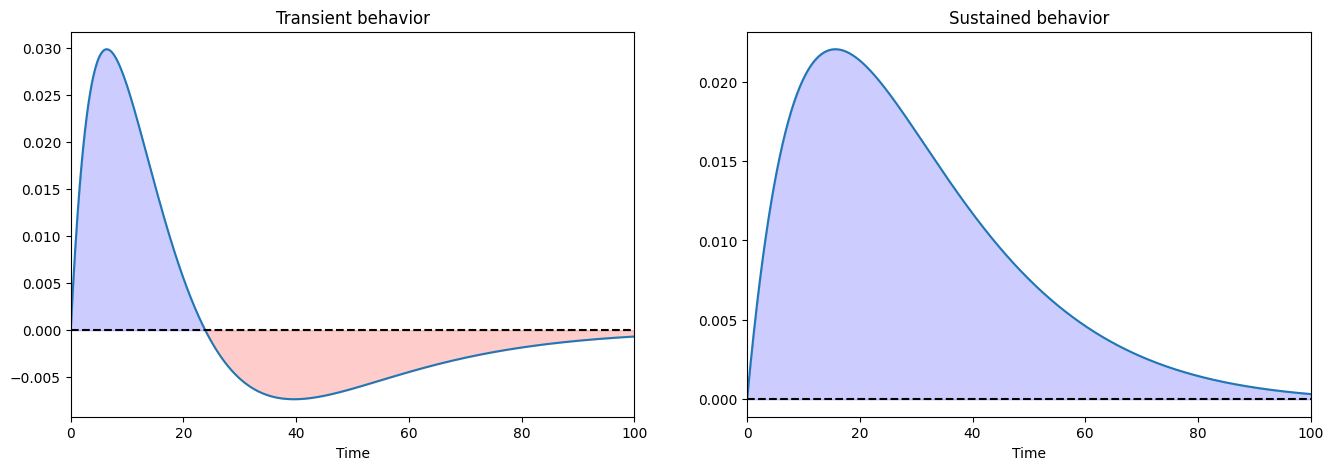

In [ ]:
# Transient response parameters
A_tr = 1.0
l_tr= 0.9
tau_1_tr = 8.0
tau_2_tr = 16.0

# Sustained response parameters
A_su = 1.0
l_su= 0.1
tau_1_su = 16
tau_2_su = 32

# Time vector
t = np.linspace(0, 100, 1000)


def double_exponential(t, A, tau_1, tau_2, l):

    out = A * ((t/tau_1**2)*np.exp(-t/tau_1) - l*(t/tau_2**2)*np.exp(-t/tau_2)) * (t >= 0) # multiply by a step function to ensure causality

    return out



fig, ax = plt.subplots(1,2, figsize=(16,5))
ax[0].plot(t, double_exponential(t, A_tr, tau_1_tr, tau_2_tr, l_tr))

# fill between curve and x axis
ax[0].fill_between(t, double_exponential(t, A_tr, tau_1_tr, tau_2_tr, l_tr), 0, where=(double_exponential(t, A_tr, tau_1_tr, tau_2_tr, l_tr) >= 0), color='blue', alpha=0.2)

# fill between curve and x axis for negative values
ax[0].fill_between(t, double_exponential(t, A_tr, tau_1_tr, tau_2_tr, l_tr), 0, where=(double_exponential(t, A_tr, tau_1_tr, tau_2_tr, l_tr) < 0), color='red', alpha=0.2)

ax[0].axhline(0, color='black', linestyle='--')

ax[0].set_title("Transient behavior")
ax[0].set_xlabel("Time")
ax[0].set_xlim([0, 100])



ax[1].plot(t, double_exponential(t, A_su, tau_1_su, tau_2_su, l_su))
# fill between curve and x axis
ax[1].fill_between(t, double_exponential(t, A_su, tau_1_su, tau_2_su, l_su), 0, where=(double_exponential(t, A_su, tau_1_su, tau_2_su, l_su) >= 0), color='blue', alpha=0.2)

# fill between curve and x axis for negative values
ax[1].fill_between(t, double_exponential(t, A_su, tau_1_su, tau_2_su, l_su), 0, where=(double_exponential(t, A_su, tau_1_su, tau_2_su, l_su) < 0), color='red', alpha=0.2)

ax[1].axhline(0, color='black', linestyle='--')

ax[1].set_title("Sustained behavior")
ax[1].set_xlabel("Time")
ax[1].set_xlim([0, 100])


# Non-separable receptive fields

Receptive fields are often classified as separable or non-separable. A separable receptive field can be written as the product of a purely spatial term and a purely temporal term: $$ h(\underline{x}, t) = g(x) \cdot f(t) $$  
Where $g$ is the spatial envelope and $f$ is the temporal envelope.
Non-separable receptive fields cannot be written in this form, because space and time are coupled. However, they can often be expressed as a sum of separable components, for example: $$h(\underline(x),t) = g(...) \cdot g(...) + \tilde{g}(...) \cdot \tilde{f}(...)$$  
This formulation shows that a non-separable receptive field can be built from multiple separable terms with different spatial and temporal dependencies.

In this section, two separable receptive fields are shown in the first two plots on the left, together with their sum, which defines the non-separable receptive field on the right. The separable components do not depend on motion direction, whereas the resulting non-separable field becomes direction-sensitive. This means that the combined response varies depending on the direction of the stimulus.

The $\alpha$ parameter act as a weight that can modify the sensitivity of the non-separable receptive field to a particular direction.

**parameters**:  
Spatial frequency $(k_0)$: controls thespatial frequency of the receptive field.  
Temporal frequency $(\omega)$: controls how rapidly the response oscillates over time.  
$\tau$: sets the temporal scale of the response, affecting how fast it evolves or decays.  
$\sigma$: controls the spatial spread of the receptive field.  
offset: shifts the phase of the response.  
weight $\alpha$: determines the contribution of one component relative to the other, and therefore modifies the directional sensitivity of the non-separable receptive field.

In [ ]:
# Setup coordinate grids
x = np.linspace(-10, 10, 200)
t = np.linspace(0, 50, 200)
X, T = np.meshgrid(x, t)


# Define the component functions

def gaussian_1d(x, sigma):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(x**2) / (2 * sigma**2))

def sust_env(t, tau):
    return (1 / tau) * np.exp(-t / tau)


def update_plot(k0, omega, tau, sigma, offset, alpha):
    
    # re_fi_1 = Gaussian * Space_Cos * Env * Time_Cos
    re_fi_1 = gaussian_1d(X, sigma) * np.cos(k0 * X - offset) * sust_env(T, tau) * np.cos(omega * T)
    
    # re_fi_2 = Gaussian * Space_Sin * Env * Time_Sin
    re_fi_2 = gaussian_1d(X, sigma) * np.sin(k0 * X - offset) * sust_env(T, tau) * np.sin(omega * T)
    
    # Sum separable receptive fields
    re_fi = alpha*re_fi_1 + (1-alpha)*re_fi_2

    fig, ax = plt.subplots(1, 3, figsize=(20, 6))
    
    titles = ['separable receptive field 1 (Cos)', 'separable receptive field 2 (Sin)', 'non-separable receptive field (Combined)']
    data = [re_fi_1, re_fi_2, re_fi]
    
    for i in range(3):
        im = ax[i].pcolormesh(X, T, data[i], cmap='gray_r', shading='auto')
        ax[i].set_title(titles[i])
        ax[i].set_xlabel("Space")
        ax[i].set_ylabel("Time")
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        # Center line
        ax[i].axvline(0, color='black', linestyle='--', alpha=0.1)
    
    # plot a red arrow indicating the direction of motion (based on k0 and omega)
    arrow_length = 5.0
    arrow_x = arrow_length * np.cos(np.arctan2(omega, k0))
    arrow_t = arrow_length * np.sin(np.arctan2(omega, k0))
    
    ax[2].arrow(0, 0, arrow_x, arrow_t, head_width=1, head_length=0.7, fc='red', ec='red', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Create the interactive sliders
interact(update_plot, 
         k0=FloatSlider(min=0, max=5, step=0.1, value=1, description='Spat Fr (k0)'),
         tau = FloatSlider(min=1, max=20, step=1, value=5, description='Tau (τ)'),
         sigma = FloatSlider(min=0.5, max=10, step=0.5, value=3, description='Sigma (σ)'),
         offset = FloatSlider(min=0, max=2*np.pi, step=0.1, value=0, description='Offset'),
         omega=FloatSlider(min=0.0, max=2, step=0.1, value=1, description='Temp Fr (ω)'), 
         alpha = FloatSlider(min=0.0, max=1.0, step=0.01, value=0.5, description='Weighting (α)'))


interactive(children=(FloatSlider(value=1.0, description='Spat Fr (k0)', max=5.0), FloatSlider(value=1.0, desc…

<function __main__.update_plot(k0, omega, tau, sigma, offset, alpha)>

# Non-separable receptive fields in frequency

This section shows the representation in frequency of a non-separable receptive field. By varying the peak frequencies in time and space it is possible to observe how the filtering properties of the 

Spatial frequency $(k_0)$: controls thespatial frequency of the receptive field.  
Temporal frequency $(\omega)$: controls how rapidly the response oscillates over time.  
$\tau$: sets the temporal scale of the response, affecting how fast it evolves or decays.  
$\sigma$: controls the spatial spread of the receptive field.  
offset: shifts the phase of the response.

In [ ]:
def update_plot_2(k0, omega, tau, sigma, offset):
    # generate grid
    x = np.linspace(-10, 10, 200)
    t = np.linspace(0, 50, 200)
    X, T = np.meshgrid(x, t)

    # calculate components
    g = gaussian_1d(X, sigma)
    env = sust_env(T, tau)
    
    # re_fi_1 = Cos/Cos, re_fi_2 = Sin/Sin
    re_fi_1 = g * np.cos(k0 * X - offset) * env * np.cos(omega * T)
    re_fi_2 = g * np.sin(k0 * X - offset) * env * np.sin(omega * T)
    
    # Combined signal (motion energy filter)
    re_fi = re_fi_1 + re_fi_2

    # compute FFT
    # abs() gives the magnitude
    F_re_fi = fftshift(fft2(re_fi))
    magnitude = np.abs(F_re_fi)

    # plotting 
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Spatial-Temporal Plot
    ax[0].pcolormesh(X, T, re_fi, cmap='gray_r', shading='auto')
    ax[0].set_title('Space-Time Domain (re_fi)')
    ax[0].set_xlabel("Space (x)")
    ax[0].set_ylabel("Time (t)")

    # Frequency Domain Plot
    ax[1].imshow(magnitude, cmap='inferno', origin='lower', extent=[-1.5, 1.5, -1.5, 1.5], aspect='auto') 
    ax[1].set_title('Frequency Domain (FFT Magnitude)')
    ax[1].set_xlabel("Spatial Freq ($f_x$)")
    ax[1].set_ylabel("Temporal Freq ($f_t$)")
    
    # lines for origin
    ax[1].axvline(0, color='white', linestyle='--', alpha=0.3)
    ax[1].axhline(0, color='white', linestyle='--', alpha=0.3)

    ax[1].set_xlim(-1.5, 1.5)
    ax[1].set_ylim(-1.5, 1.5)

    plt.tight_layout()
    plt.show()

# interactive plot
interact(update_plot_2, 
         k0=FloatSlider(min=0, max=20, step=0.1, value=1, description='Spat Fr (k0)'),
         tau=FloatSlider(min=0.05, max=30, step=0.01, value=10, description='Tau'),
         sigma=FloatSlider(min=0.05, max=10, step=0.01, value=3, description='Sigma'),
         offset=FloatSlider(min=0, max=2*np.pi, step=0.1, value=0, description='Offset'),
         omega=FloatSlider(min=0.0, max=10, step=0.1, value=1, description='Temp Fr (ω)'))

interactive(children=(FloatSlider(value=1.0, description='Spat Fr (k0)', max=20.0), FloatSlider(value=1.0, des…

<function __main__.update_plot_2(k0, omega, tau, sigma, offset)>

# Gaussian pyramid

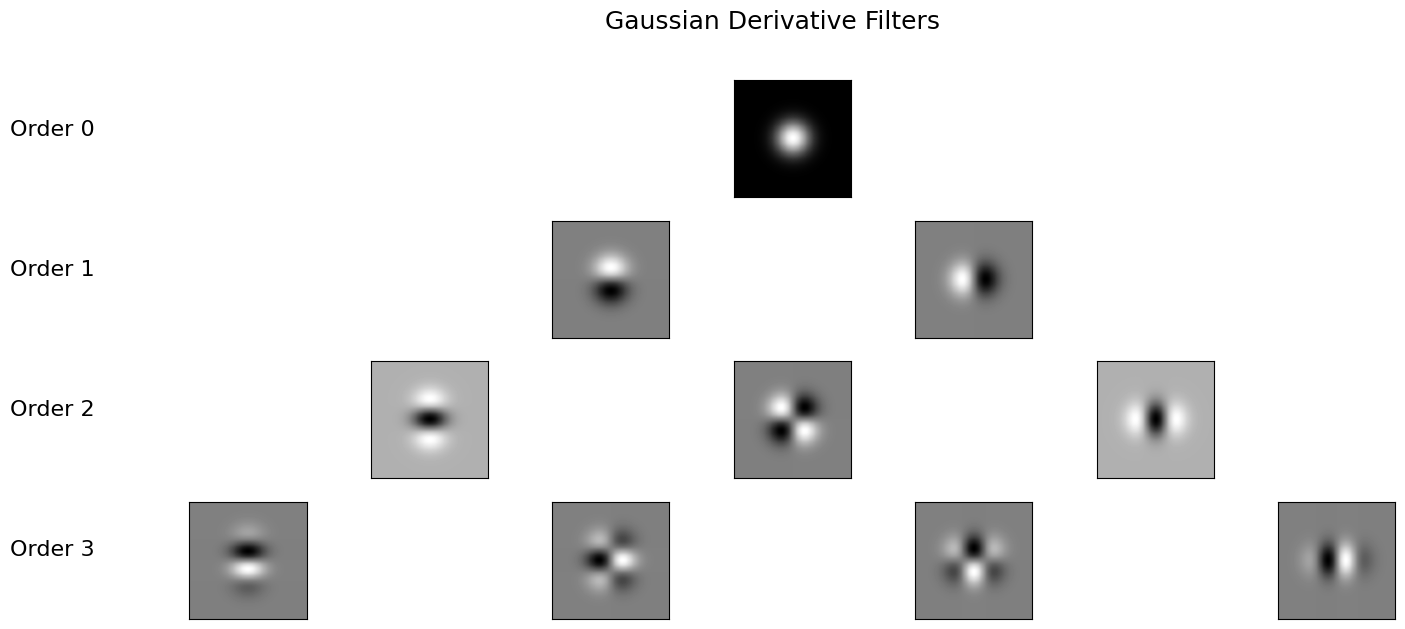

In [40]:
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(16,7))
subp = fig.add_gridspec(4, 7) 

ax = np.zeros(10, dtype=object)

X,Y = np.meshgrid(np.linspace(-5,5,100), np.linspace(-5,5,100))

gauss = gaussian_2d(X, Y, sigma=1.0)

ax[0] = fig.add_subplot(subp[0, 3])
ax[0].imshow(gauss, extent=(-5, 5, -5, 5), cmap='gray')

ax[1] = fig.add_subplot(subp[1, 2])
ax[1].imshow(np.diff(gauss, axis=0), extent=(-5, 5, -5, 5), cmap='gray')
ax[2] = fig.add_subplot(subp[1, 4])
ax[2].imshow(np.diff(gauss, axis=1), extent=(-5, 5, -5, 5), cmap='gray')

fig.text(0.05, 0.8, 'Order 0', ha='center', fontsize=16)
fig.text(0.05, 0.6, 'Order 1', ha='center', fontsize=16)
fig.text(0.05, 0.4, 'Order 2', ha='center', fontsize=16)
fig.text(0.05, 0.2, 'Order 3', ha='center', fontsize=16)


ax[3] = fig.add_subplot(subp[2, 1])
ax[3].imshow(np.diff(np.diff(gauss, axis=0), axis=0), extent=(-5, 5, -5, 5), cmap='gray')
ax[4] = fig.add_subplot(subp[2, 3])
ax[4].imshow(np.diff(np.diff(gauss, axis=0), axis=1), extent=(-5, 5, -5, 5), cmap='gray')
ax[5] = fig.add_subplot(subp[2, 5])
ax[5].imshow(np.diff(np.diff(gauss, axis=1), axis=1), extent=(-5, 5, -5, 5), cmap='gray')


ax[6] = fig.add_subplot(subp[3, 0])
ax[6].imshow(np.diff(np.diff(np.diff(gauss, axis=0), axis=0), axis=0), extent=(-5, 5, -5, 5), cmap='gray')
ax[7] = fig.add_subplot(subp[3, 2])
ax[7].imshow(np.diff(np.diff(np.diff(gauss, axis=0), axis=0), axis=1), extent=(-5, 5, -5, 5), cmap='gray')
ax[8] = fig.add_subplot(subp[3, 4])
ax[8].imshow(np.diff(np.diff(np.diff(gauss, axis=1), axis=1), axis=0), extent=(-5, 5, -5, 5), cmap='gray')
ax[9] = fig.add_subplot(subp[3, 6])
ax[9].imshow(np.diff(np.diff(np.diff(gauss, axis=1), axis=1), axis=1), extent=(-5, 5, -5, 5), cmap='gray')

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

fig.suptitle('Gaussian Derivative Filters', fontsize=18)
plt.show()

# Steerability

In [ ]:
# Define grid
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
gauss = np.exp(-(X**2 + Y**2))

# Gradients
gauss_x = np.diff(gauss, axis=1, append=0) 
gauss_y = np.diff(gauss, axis=0, append=0)

# Find the global maximum value across both components to fix the scale
v_limit = max(np.abs(gauss_x).max(), np.abs(gauss_y).max())

def plot_steerable_filter(theta):

    # Calculate components
    comp_x = gauss_x * np.cos(theta - np.pi/2)
    comp_y = gauss_y * np.sin(theta - np.pi/2)
    result = comp_x + comp_y

    fig = plt.figure(figsize=(14, 7))
    gs = fig.add_gridspec(2, 3) 
    
    # Using 'RdBu_r' (Red-Blue reversed) so positive is red, negative is blue
    style_kwargs = {
        'extent': (-5, 5, -5, 5),
        'cmap': 'gray', 
        'vmin': -v_limit, 
        'vmax': v_limit
    }

   # plot
    ax_main = fig.add_subplot(gs[0, 1])
    ax_main.set_title(f"Combined Filter $G_{{\\theta}}$\n$\\theta$ = {theta/np.pi:.2f}$\\pi$", fontsize=12)
    im_main = ax_main.imshow(result, **style_kwargs)

    # X Component
    ax_x = fig.add_subplot(gs[1, 0])
    ax_x.set_title(r"$\frac{\partial G}{\partial x} \cos(\theta - \pi/2)$")
    im_x = ax_x.imshow(comp_x, **style_kwargs)

    # Y Component
    ax_y = fig.add_subplot(gs[1, 2])
    ax_y.set_title(r"$\frac{\partial G}{\partial y} \sin(\theta - \pi/2)$")
    im_y = ax_y.imshow(comp_y, **style_kwargs)

    for ax in fig.axes:
        ax.set_xticks([])
        ax.set_yticks([])
        
    plt.tight_layout()
    plt.show()

interact(plot_steerable_filter, 
         theta=FloatSlider(min=0, max=2*np.pi, step=0.1, value=np.pi/4, description=fr"Theta (θ)"))

interactive(children=(FloatSlider(value=0.7853981633974483, description='Theta (θ)', max=6.283185307179586), O…

<function __main__.plot_steerable_filter(theta)>